# Simple Linear Regression – House Price Prediction

## Project Overview

This project demonstrates the use of Simple Linear Regression to predict house prices based on a selected numerical feature from a housing dataset.

### Objectives

The main objectives of this project are:

- Load and explore the house price dataset.
- Understand the relationship between the input feature and house price.
- Prepare the data for machine learning.
- Split the dataset into training and testing sets.
- Build a Simple Linear Regression model.
- Train the model using the training data.
- Predict house prices using the trained model.
- Evaluate the model's performance.
- Visualize the regression line and predictions.

### Tools and Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

In [1]:
import pandas as pd

# Load the house price dataset
df = pd.read_csv("../data/House_Price.csv")

print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks
0,24.0,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.480,11.1920,River,23,YES,0.049347
1,21.6,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,NO,7.332,12.1728,Lake,42,YES,0.046146
2,34.7,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,NO,7.394,101.1200,NaN,38,YES,0.045764
3,33.4,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,YES,9.268,11.2672,Lake,45,YES,0.047151
4,36.2,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,NO,8.824,11.2896,Lake,55,YES,0.039474


In [2]:
# Explore the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (506, 19)

Column Names:
['price', 'crime_rate', 'resid_area', 'air_qual', 'room_num', 'age', 'dist1', 'dist2', 'dist3', 'dist4', 'teachers', 'poor_prop', 'airport', 'n_hos_beds', 'n_hot_rooms', 'waterbody', 'rainfall', 'bus_ter', 'parks']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        506 non-null    float64
 1   crime_rate   506 non-null    float64
 2   resid_area   506 non-null    float64
 3   air_qual     506 non-null    float64
 4   room_num     506 non-null    float64
 5   age          506 non-null    float64
 6   dist1        506 non-null    float64
 7   dist2        506 non-null    float64
 8   dist3        506 non-null    float64
 9   dist4        506 non-null    float64
 10  teachers     506 non-null    float64
 11  poor_prop    506 non-null    float64
 12  airport      506 non-null

In [3]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
price            0
crime_rate       0
resid_area       0
air_qual         0
room_num         0
age              0
dist1            0
dist2            0
dist3            0
dist4            0
teachers         0
poor_prop        0
airport          0
n_hos_beds       8
n_hot_rooms      0
waterbody      155
rainfall         0
bus_ter          0
parks            0
dtype: int64


In [4]:
# Check correlation of numerical features with house price

correlation = df.corr(numeric_only=True)["price"].sort_values(ascending=False)

print("Correlation with House Price:")
print(correlation)

Correlation with House Price:
price          1.000000
room_num       0.696304
teachers       0.505655
dist1          0.251355
dist2          0.249459
dist4          0.248200
dist3          0.246650
n_hos_beds     0.109646
n_hot_rooms    0.023122
rainfall      -0.047426
age           -0.377999
crime_rate    -0.389582
parks         -0.391574
air_qual      -0.429300
resid_area    -0.484754
poor_prop     -0.740836
Name: price, dtype: float64


In [5]:
# Select feature and target variables

X = df[["room_num"]]
y = df["price"]

print("Feature (X): room_num")
print("Target (y): price")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Feature (X): room_num
Target (y): price

Feature shape: (506, 1)
Target shape: (506,)


In [6]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (404, 1)
Testing feature shape: (102, 1)
Training target shape: (404,)
Testing target shape: (102,)


In [7]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [8]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("\nFirst 10 predicted house prices:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predicted house prices:
[23.73724121 26.93319965 19.69089617 20.4571786  22.62519719 22.45698885
 19.04609753 21.47577354 21.98974346 20.1020721 ]


In [9]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Model Evaluation
-----------------
Mean Squared Error (MSE): 46.630761887451136
R² Score: 0.3676692756441877


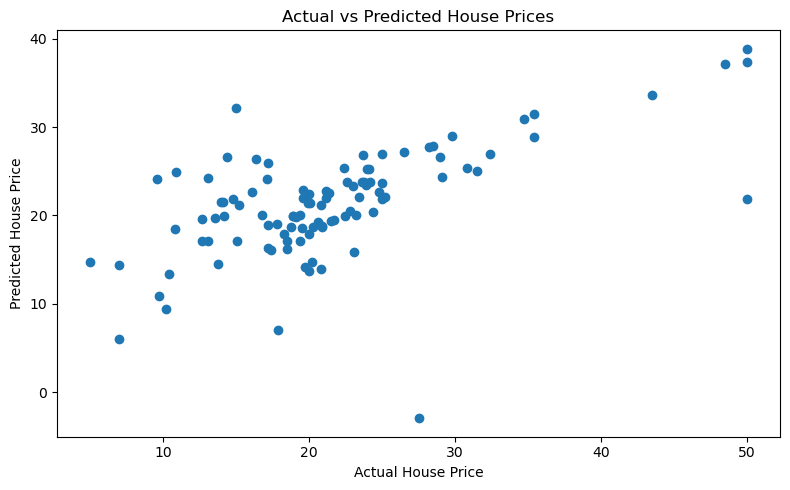

In [10]:
import matplotlib.pyplot as plt

# Plot actual vs predicted prices
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.tight_layout()
plt.show()

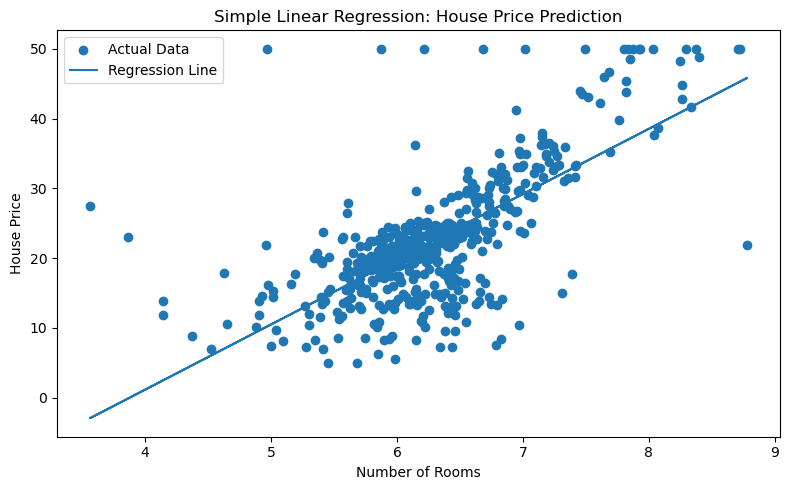

In [11]:
# Plot the regression line

plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Actual Data")

# Generate predictions for the complete dataset
y_line = model.predict(X)

plt.plot(X, y_line, label="Regression Line")

plt.xlabel("Number of Rooms")
plt.ylabel("House Price")
plt.title("Simple Linear Regression: House Price Prediction")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# Display the regression equation

slope = model.coef_[0]
intercept = model.intercept_

print("Regression Model Parameters")
print("---------------------------")
print("Slope:", slope)
print("Intercept:", intercept)

print("\nRegression Equation:")
print(f"Price = {intercept:.2f} + ({slope:.2f} × room_num)")

Regression Model Parameters
---------------------------
Slope: 9.344907718093513
Intercept: -36.21968671198458

Regression Equation:
Price = -36.22 + (9.34 × room_num)


In [13]:
# Predict the price of a new house

new_house = pd.DataFrame({
    "room_num": [6.5]
})

predicted_price = model.predict(new_house)

print("Number of Rooms:", new_house["room_num"].iloc[0])
print(f"Predicted House Price: {predicted_price[0]:.2f}")

Number of Rooms: 6.5
Predicted House Price: 24.52


## Actual vs Predicted Price Comparison

In [14]:
# Create a comparison table of actual and predicted prices

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

display(results.head(10))

,Actual Price,Predicted Price
0,23.6,23.737241
1,32.4,26.933200
2,13.6,19.690896
3,22.8,20.457179
4,16.1,22.625197
5,20.0,22.456989
6,17.8,19.046098
7,14.0,21.475774
8,19.6,21.989743
9,16.8,20.102072


In [15]:
# Save prediction results

results.to_csv("../output/prediction_results.csv", index=False)

print("Prediction results saved successfully!")

Prediction results saved successfully!


## Final Model Summary

The Simple Linear Regression model was trained to predict house prices using the number of rooms (`room_num`) as the input feature.

The model was evaluated using Mean Squared Error (MSE) and R² Score. A regression equation was also generated to describe the relationship between the number of rooms and predicted house price.

In [16]:
# Final model summary

print("===== Final Model Summary =====")
print(f"Feature Used: room_num")
print(f"Target: price")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Regression Equation: Price = {intercept:.2f} + ({slope:.2f} × room_num)")

===== Final Model Summary =====
Feature Used: room_num
Target: price
Training Samples: 404
Testing Samples: 102
MSE: 46.6308
R² Score: 0.3677
Slope: 9.3449
Intercept: -36.2197
Regression Equation: Price = -36.22 + (9.34 × room_num)
